When dealing with geospatial data, analyzing single images can provide detailed insights into specific temporal snapshots of a region. Unlike animations that track changes over time, working with individual images allows for a focused examination of spatial characteristics of a region at a given moment. Google Earth Engine offers robust tools for accessing and processing these images, enabling researchers to extract valuable information from diverse datasets. This tutorial will guide you through the process of retrieving and analyzing single images from Google Earth Engine.

This tutorial focuses on static properties that do not change substantially over time, like elevation above sea level and some soil properties.

In [1]:
# Import modules
import ee
import requests
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import colors, colormaps
from pprint import pprint
import json
from datetime import datetime
import io

In [2]:
# Authenticate
# ee.Authenticate()

# Initialize the library.
ee.Initialize()


## Define helper functions

In [3]:
# Define function to save images to the local drive 
def save_geotiff(ee_image, filename, crs, scale, geom, bands=[]):
    """
    Function to save images from Google Earth Engine into local hard drive.
    """
    image_url = ee_image.getDownloadUrl({'region': geom,'scale':scale, 
                                         'bands': bands,
                                         'crs': f'EPSG:{crs}', 
                                         'format': 'GEO_TIFF'})
    
    # Request data using URL and save data as a new GeoTiff file
    response = requests.get(image_url)
    with open(filename, 'wb') as f:
        f.write(response.content)
        return print('Saved image')



## Example 1: State level elevation

In [4]:
# Read US states
US_states = ee.FeatureCollection("TIGER/2018/States")

# Select Kansas
region = US_states.filter(ee.Filter.eq('NAME','Kansas'))

# Create mask (pixels inside the region have a value of 1, which we use to hide pixels outside the state)
mask = ee.Image.constant(1).clip(region).mask()


In [5]:
# Get image with elevation data from the Shuttle Radar Topography Mission (SRTM)
srtm = ee.Image("USGS/SRTMGL1_003")
elev_img = srtm.clip(region).mask(mask)


In [6]:
# Save geotiff
elev_filename = '../outputs/kansas_elevation_250m.tif'
save_geotiff(elev_img, elev_filename, crs=4326, scale=250, geom=region.geometry())


Saved image


In [7]:
# Read GeoTiff file using Xarray (and remove extra dimension)
elev_raster = xr.open_dataarray(elev_filename).squeeze()


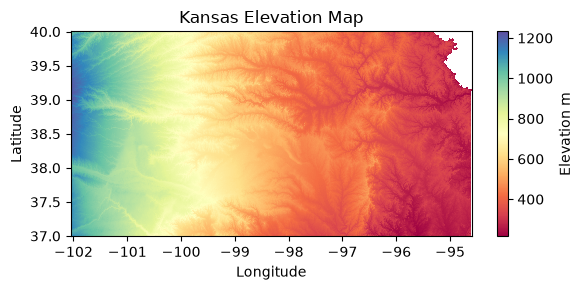

In [8]:
# Create figure
elev_raster.plot.imshow(figsize=(6,3), cmap='Spectral', add_colorbar=True,
                   cbar_kwargs={'label':'Elevation m'});
plt.title('Kansas Elevation Map')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.axis('equal')
plt.tight_layout()
plt.show()


## Example 2: State level soil textural class

In this example we will plot the 12 soil textural classes for the state of Kansas. We will also learn how to use Matplotlib's object-based syntax to define a colorbar with custom labels. The source for this example is from the 800-meter spatial resolution gridded soil product created by Walkinshaw et al. (2020) using the USDA-NRCS Soil Survey Geodatabase. Check out the link below for some cool maps:

- Walkinshaw, Mike, A.T. O'Geen, D.E. Beaudette. "Soil Properties." California Soil Resource Lab, 1 Oct. 2020,
casoilresource.lawr.ucdavis.edu/soil-properties/.

In [9]:
# Read US states
US_states = ee.FeatureCollection("TIGER/2018/States")

# Select Kansas
region = US_states.filter(ee.Filter.eq('NAME','Kansas'))

# Create mask
mask = ee.Image.constant(1).clip(region).mask()

In [10]:
url_link = 'projects/earthengine-legacy/assets/projects/sat-io/open-datasets/CSRL_soil_properties/physical/soil_texture_profile/texture_025'
texture_img = ee.Image(url_link).clip(region).mask(mask)

# Palette
palette = ['#BEBEBE', #Sand
           '#FDFD9E', #Loamy Sand
           '#ebd834', #Sandy Loam
           '#307431', #Loam
           '#CD94EA', #Silt Loam
           '#546BC3', #Silt
           '#92C158', #Sandy Clay Loam
           '#EA6996', #Clay Loam
           '#6D94E5', #Silty Clay Loam
           '#4C5323', #Sandy Clay
           '#E93F4A', #Silty Clay
           '#AF4732', #Clay
          ]

# Visualization parameters
texture_cmap = colors.ListedColormap(palette)

# Save geotiff
texture_filename = '../outputs/kansas_texture_800m.tif'
save_geotiff(texture_img, texture_filename, crs=4326, scale=800, geom=region.geometry())


Saved image


In [11]:
# Read saved geotiff image
texture_raster = xr.open_dataarray(texture_filename).squeeze()


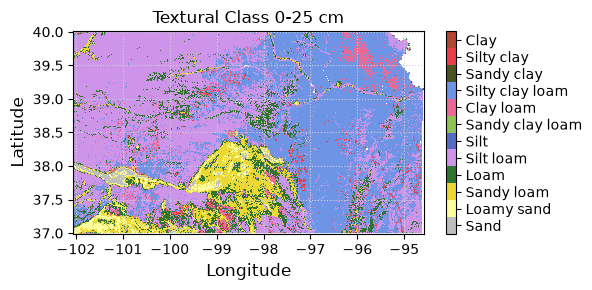

In [12]:
fig, ax = plt.subplots(figsize=(6,3))

raster = texture_raster.plot.imshow(ax=ax, cmap=texture_cmap, 
                                    add_colorbar=False, vmin=1, vmax=13)

ax.set_title('Textural Class 0-25 cm')
ax.set_ylabel('Latitude', fontsize=12)
ax.set_xlabel('Longitude', fontsize=12)
ax.grid(which='major', color='lightgrey', linestyle=':')

# Add colorbar
cbar = fig.colorbar(raster, ax=ax)

# Customize the colorbar
cbar.set_ticks(ticks=np.linspace(1.5, 12.5, 12),
               labels=['Sand','Loamy sand','Sandy loam',
                       'Loam','Silt loam','Silt',
                       'Sandy clay loam','Clay loam',
                       'Silty clay loam','Sandy clay',
                       'Silty clay','Clay'])

plt.tight_layout()
#plt.savefig('flint_hills.jpg', dpi=300)
plt.show()


## Example 3: Regional soil properties

In [13]:
# Ecoregions map
# https://developers.google.com/earth-engine/datasets/catalog/RESOLVE_ECOREGIONS_2017#description
eco_regions = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017")

# Select flint hills region
region = eco_regions.filter(ee.Filter.inList('ECO_ID',[392])) # Find ecoregion ID using their website: https://ecoregions.appspot.com

# Define approximate region bounding box [E,S,W,N]
bbox = ee.Geometry.Rectangle([-95.6, 36, -97.4, 40])

# Create mask for the region
mask = ee.Image.constant(1).clip(region).mask()


#### Load maps of soil physical properties

In [14]:
# SAND

# Select layer, clip to region, and then mask
sand = ee.Image("projects/soilgrids-isric/sand_mean").clip(region).mask(mask)
sand_img = sand.select('sand_0-5cm_mean').multiply(0.1) # From g/kg to %


# Save geotiff
sand_filename = '../outputs/flint_hills_sand_250m.tif'
save_geotiff(sand_img, sand_filename, crs=4326, scale=250, geom=region.geometry())


Saved image


In [15]:
# SOIL ORGANIC CARBON

# Select layer, clip to region, and then mask
soc = ee.Image("projects/soilgrids-isric/soc_mean").clip(region).mask(mask)

# Select surface soil organic carbon layer
soc_img = soc.select('soc_0-5cm_mean').multiply(0.01) # From dg/kg to %


# Save geotiff
soc_filename = '../outputs/flint_hills_soc_250m.tif'
save_geotiff(soc_img, soc_filename, crs=4326, scale=250, geom=region.geometry())


Saved image


In [16]:
# Read GeoTiff images saved in our local drive
sand_raster = xr.open_dataarray(sand_filename).squeeze()
soc_raster = xr.open_dataarray(soc_filename).squeeze()


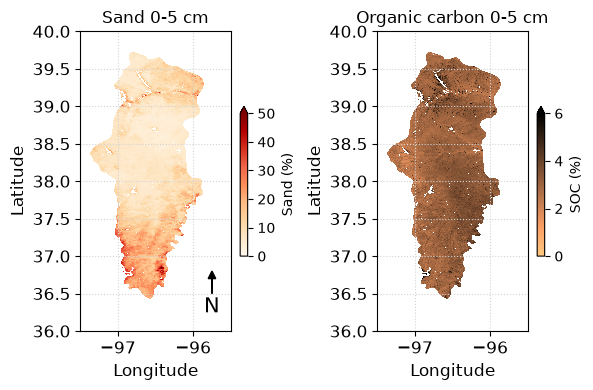

In [17]:
# Create figure
fs = 12 # Define font size variable

plt.figure(figsize=(6,4))

plt.subplot(1,2,1)
sand_raster.plot.imshow(cmap='OrRd', add_colorbar=True, vmin=0, vmax=50,
                   cbar_kwargs={'label':'Sand (%)', 'shrink':0.5});
plt.title('Sand 0-5 cm')
plt.xlabel('Longitude', fontsize=fs)
plt.ylabel('Latitude', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.grid(which='major', color='lightgrey', linestyle=':')
plt.arrow(-95.75, 36.5, 0, 0.2, head_width=0.1, head_length=0.1, fc='k', ec='k')
plt.text(-95.75, 36.25, 'N', fontsize=15, ha='center')
plt.xlim([-97.5, -95.5])
plt.ylim([36, 40])


plt.subplot(1,2,2)
soc_raster.plot.imshow(cmap='copper_r', add_colorbar=True, vmin=0, vmax=6,
                   cbar_kwargs={'label':'SOC (%)', 'shrink':0.5});
plt.title('Organic carbon 0-5 cm')
plt.xlabel('Longitude', fontsize=fs)
plt.ylabel('Latitude', fontsize=fs)
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.grid(which='major', color='lightgrey', linestyle=':')
plt.xlim([-97.5, -95.5])
plt.ylim([36,40])

plt.tight_layout()
plt.show()


## Example 4: Regional drought

In this example we will explore how to retrieve available dates for an Image Collection and then we will use that information to select a specific Image. More specifically, to illustrate these concepts we will use the collection from the U.S. Drought Monitor, which releases weekly maps of drought conditions for the United States. The selected region for the map is the area covering the Ogallala aquifer, which is one of the largest aquifers in the world spanning multiple states in the U.S. Great Plains.

#### Read boundary

In [18]:
# Import boundary for Ogallala Aquifer from local drive
filename_bnd = '../datasets/ogallala_aquifer_bnd.geojson'

# Read the file
with open(filename_bnd) as file:
    roi_json = json.load(file)

# Get coordinates for plot
lon,lat = zip(*roi_json['features'][0]['geometry']['coordinates'][0])

# Define the ee.Geometry so that GEE can use it
roi_geom = ee.Geometry(roi_json['features'][0]['geometry'])

# Create mask
mask = ee.Image.constant(1).clip(roi_geom).mask()


#### Load USDM image collection

In [19]:
# Load U.S. Drought monitor Image Collection
usdm_collection = ee.ImageCollection("projects/sat-io/open-datasets/us-drought-monitor")


To access a specific number of items from a collection, we can use the `.toList()` method. For instance, to return the first three images of the U.S. Drought Monitor collection defined above we can run the following command: `usdm_collection.toList(3).getInfo()`

In [20]:
# Define function to get dates from each ee.Image object
get_date = lambda image: ee.Image(image).date().format('YYYY-MM-dd')

# Get the size of the image collection
N = usdm_collection.size()


# Apply function to collection
usdm_dates = usdm_collection.toList(N).map(get_date).getInfo()

# Iterate over all the dates and select images for October 2012
for k,date in enumerate(usdm_dates):
    date = datetime.strptime(date, '%Y-%m-%d')
    if date.year == 2012 and date.month == 10:
        print(k, date)


666 2012-10-02 00:00:00
667 2012-10-09 00:00:00
668 2012-10-16 00:00:00
669 2012-10-23 00:00:00
670 2012-10-30 00:00:00


Note that the following code will not work:

```python
get_date = lambda image: image.date().format('YYYY-MM-dd')
usdm_dates = usdm_collection.map(get_date).getInfo()
```

The reason it does not work is because a mapping algorithm on a collection must return a Feature or Image, and the above code returns a date string.



In [21]:
# Read specific image
image_number = 670
usdm_img = ee.Image(usdm_collection.toList(N).get(image_number))

# Clip and add 1 to the layer, so that we represent "None" as 0
usdm_img = usdm_img.clip(roi_geom).add(1).mask(mask)

# Get latest image of collection
# usdm_img = ee.Image(usdm_collection.toList(N).get(-1)).mask(mask)

# Get first image of collection
# usdm_img = ee.Image(usdm_collection.toList(N).get(0)).mask(mask) # or
# usdm_img = usdm_collection.first().mask(mask)


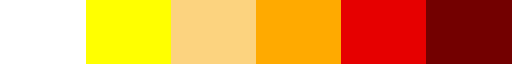

In [22]:
# Define colormap
usdm_hex_palette = ["#FFFFFF", "#FFFF00", "#FCD37F", "#FFAA00", "#E60000", "#730000"]

# Visualization parameters
usdm_cmap = colors.ListedColormap(usdm_hex_palette)
usdm_cmap

In [23]:
# Get map from url (it may take several seconds)
image_url = usdm_img.getDownloadUrl({
    'region': roi_geom,
    'scale':1_000,
    'crs': 'EPSG:4326',
    'format': 'GEO_TIFF'})

# Request data using URL and save data as a new GeoTiff file
response = requests.get(image_url)
   

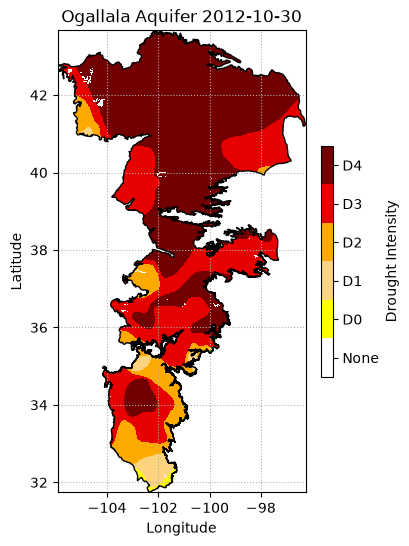

In [24]:
# Check if the request was successful
if response.status_code == 200:
    
    # Read image data into a BytesIO object
    image_data = io.BytesIO(response.content)
    
    fig,ax = plt.subplots(figsize=(4,6))
    
    # Use Xarray to open the raster image directly from memory
    raster = xr.open_dataarray(image_data, engine='rasterio').squeeze()
    
    # Create raster map showing drought conditions
    usdm_map = raster.plot.imshow(ax=ax, cmap=usdm_cmap, 
                                  vmin=-0.5, vmax=5.5, add_colorbar=False)
    
    # Add aquifer boundaries
    ax.plot(lon, lat, color='k', linewidth=1)
    
    # Add colorbar
    cbar = fig.colorbar(usdm_map, ax=ax, shrink=0.5, label='Drought Intensity')

    # Add labels in the center of each segment
    cbar.set_ticks(ticks=[0,1,2,3,4,5],
                   labels=['None','D0','D1','D2','D3','D4'])

    # Add labels
    ax.set_title(f'Ogallala Aquifer {usdm_dates[image_number]}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.grid(linestyle=':')
    plt.show()
    